# 1. READING AND DISPLAYING IMAGES IN PYTHON

## 1.1 Lectura y propiedades básicas de una imagen

¿Cómo lee Python una imagen con Scikit-Image?

Usamos la función io.imread('nombre_archivo'). Al leer la imagen, Python no guarda "píxeles visuales", sino una matriz numérica de NumPy:   

- Imagen en escala de grises: Se guarda como una matriz 2D de dimensiones $N \times M$, donde $N$ es el alto (eje $Y$) y $M$ el ancho (eje $X$).   
- Imagen a color: Se guarda como una matriz 3D de dimensiones $N \times M \times 3$, donde la tercera dimensión tiene 3 canales: Rojo (R), Verde (G) y Azul (B).   

¿Qué información debemos inspeccionar?   

- Dimensiones (img.shape): Nos dirá $(N, M)$ si es escala de grises o $(N, M, 3)$ si es color.   
- Rango de valores (img.min() y img.max()): Típicamente, si el formato es entero sin signo de 8 bits (uint8), los valores de intensidad van del $0$ (negro puro) al $255$ (blanco puro).   
- Visualización (plt.imshow): Para mostrar la imagen. En matplotlib, si es una imagen de 2 dimensiones (escala de grises), debemos añadir explícitamente el parámetro cmap='gray'. De lo contrario, matplotlib aplicará por defecto un mapa de calor falso (pseudocolor verde/amarillo).

Dimensiones de la imagen (N x M): (519, 880)
¿Es una imagen a color?: False
Rango de valores de los píxeles: Min = 0, Max = 255


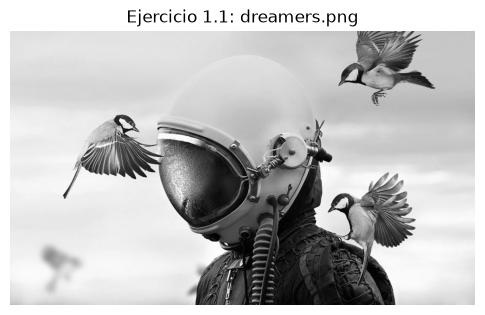

In [2]:
import matplotlib.pyplot as plt
from skimage import io

# 1. Leer la imagen 'dreamers.png'
img_dreamers = io.imread('dreamers.png')

# 2. Inspeccionar sus propiedades
shape = img_dreamers.shape
min_val = img_dreamers.min()
max_val = img_dreamers.max()

# Determinar si es color o escala de grises según sus dimensiones (ndim)
is_color = img_dreamers.ndim == 3 and shape[2] == 3

print(f"Dimensiones de la imagen (N x M): {shape}")
print(f"¿Es una imagen a color?: {is_color}")
print(f"Rango de valores de los píxeles: Min = {min_val}, Max = {max_val}")

# 3. Mostrar la imagen en escala de grises
plt.figure(figsize=(6, 6))
# Usamos cmap='gray' si la matriz tiene 2 dimensiones
if not is_color:
    plt.imshow(img_dreamers, cmap='gray')
else:
    plt.imshow(img_dreamers)

plt.title('Ejercicio 1.1: dreamers.png')
plt.axis('off')
plt.show()

## 1.2 Manipulación de componentes de color

Una imagen RGB es una matriz 3D (N, M, 3). En Python (indexación desde 0):   

- peppers[:, :, 0] es la matriz 2D del canal Rojo (Red).
- peppers[:, :, 1] es la matriz 2D del canal Verde (Green).
- peppers[:, :, 2] es la matriz 2D del canal Azul (Blue).

El ejercicio nos pide mostrar la componente roja de tres formas distintas:   

Como matriz 2D en escala de grises 
Extraemos peppers[:, :, 0] y la mostramos con cmap='gray'.   
¿Cómo comprobar visualmente si es correcta? En la imagen original, los pimientos rojos deben verse muy brillantes (blancos o gris claro) en el canal R, mientras que los pimientos verdes y el fondo oscuro deben verse más oscuros.

En pseudocolor (mapa de colores jet):

Usamos la misma matriz 2D del canal R pero cambiando la paleta visual a cmap='jet'. Esto asignará colores cálidos (rojo/amarillo) a las zonas de alta intensidad y colores fríos (azul) a las zonas de baja intensidad.   

Como imagen a color real (True Color) modificada:

Creamos una copia de la imagen a color de 3 dimensiones (N, M, 3) y ponemos a cero los canales Verde y Azul (peppers_red_only[:, :, 1] = 0 y peppers_red_only[:, :, 2] = 0). Al mostrarla con plt.imshow, veremos la foto original teñida completamente de rojo. 

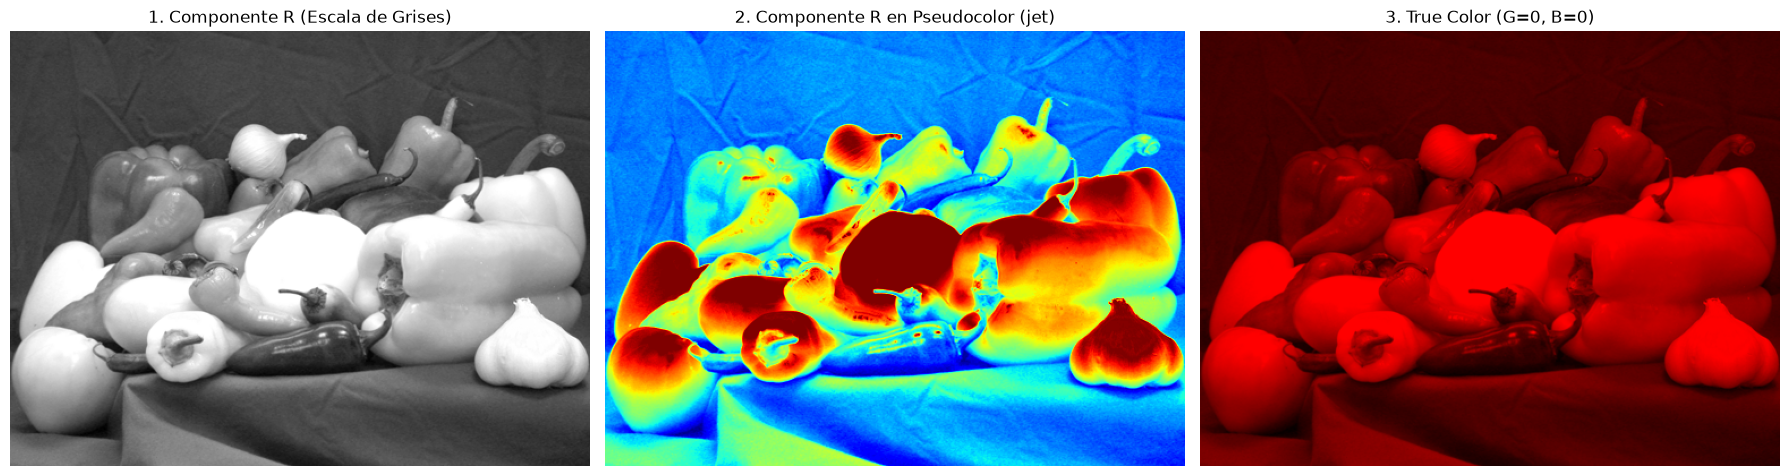

In [3]:
# 1. Leer la imagen 'peppers.png'
img_peppers = io.imread('peppers.png')

# Si la imagen se lee con 4 canales (RGBA), dejamos solo los 3 primeros (RGB)
if img_peppers.ndim == 3 and img_peppers.shape[2] == 4:
    img_peppers = img_peppers[:, :, :3]

# 2. Extraer la componente roja como matriz 2D
red_channel_2d = img_peppers[:, :, 0]

# 3. Crear una copia de la imagen a color y poner G y B a cero
red_true_color = img_peppers.copy()
red_true_color[:, :, 1] = 0  # Canal Verde = 0
red_true_color[:, :, 2] = 0  # Canal Azul = 0

# 4. Visualización en una sola figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A. Componente R en Escala de Grises
axes[0].imshow(red_channel_2d, cmap='gray')
axes[0].set_title('1. Componente R (Escala de Grises)')
axes[0].axis('off')

# B. Componente R en Pseudocolor (jet)
axes[1].imshow(red_channel_2d, cmap='jet')
axes[1].set_title('2. Componente R en Pseudocolor (jet)')
axes[1].axis('off')

# C. Imagen True Color solo con canal R (G=0, B=0)
axes[2].imshow(red_true_color)
axes[2].set_title('3. True Color (G=0, B=0)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 2. COLOR REPRESENTATION: RGB AND HSV

## 2.1 Análisis de los Espacios de Color RGB y HSV

Componentes RGB:
- R (Red), G (Green), B (Blue) representan directamente la cantidad de luz roja, verde y azul de cada píxel.   
- Los mostraremos por separado en una sola figura usando plt.subplot.   

Espacio HSV (Hue, Saturation, Value):
- H (Hue / Tono): Representa el ángulo del color puro (rojo, verde, azul, amarillo, etc.). En skimage.color.rgb2hsv, los valores de $H$ están normalizados en el rango $[0, 1]$.    El valor $H = 0.0$ (o $1.0$, ya que es circular de $0^\circ$ a $360^\circ$) representa el color Rojo.
- S (Saturation / Saturación): Indica la pureza o intensidad del color (rango $[0, 1]$). Un valor de $0$ es gris neutro (sin color) y $1$ es color puro saturado.   
- V (Value / Brillo): Representa el brillo general del píxel (rango $[0, 1]$). $0$ es negro absoluto y $1$ es brillo máximo.   

¿Qué rango tiene la componente H? 

En skimage, el rango de $H$ es $[0.0, 1.0]$ (mapeado desde $0^\circ$ a $360^\circ$).   

¿Qué valor de H representa el rojo? 

El valor $0.0$ (o cercano a $1.0$).   ¿Cómo codifica HSV el color blanco? El blanco no tiene tono ni color puro saturado. Por lo tanto, el blanco se representa con Saturación $S = 0$ y Brillo $V = 1$ (con cualquier valor de $H$).

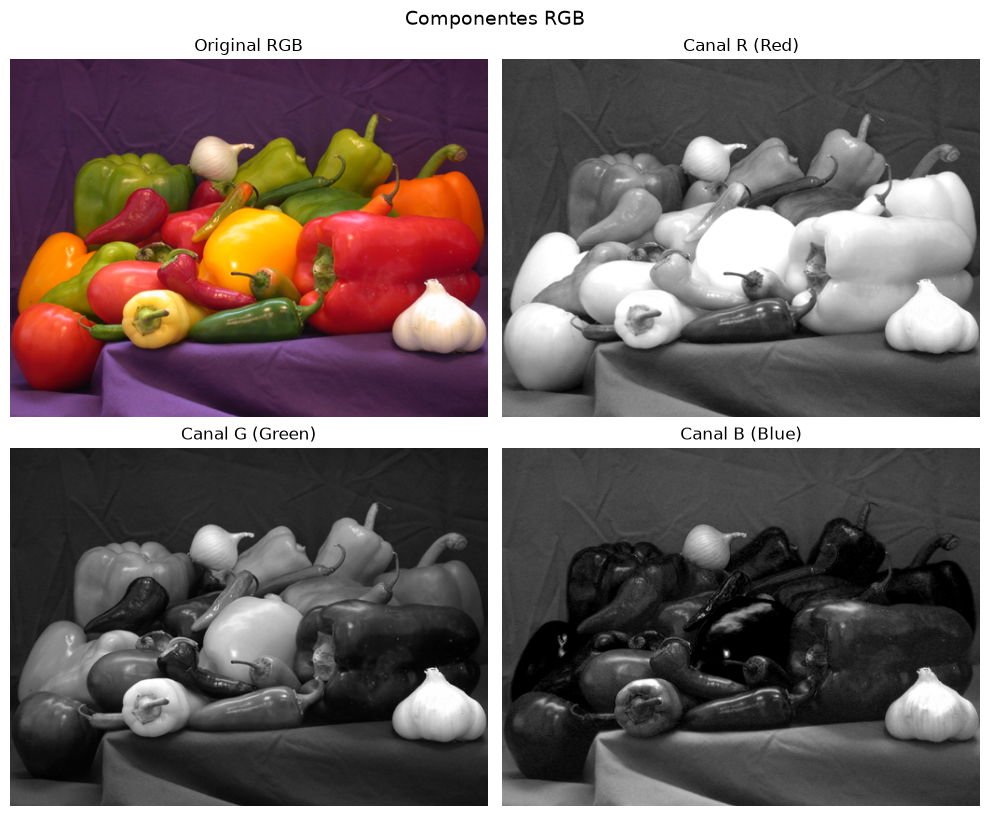

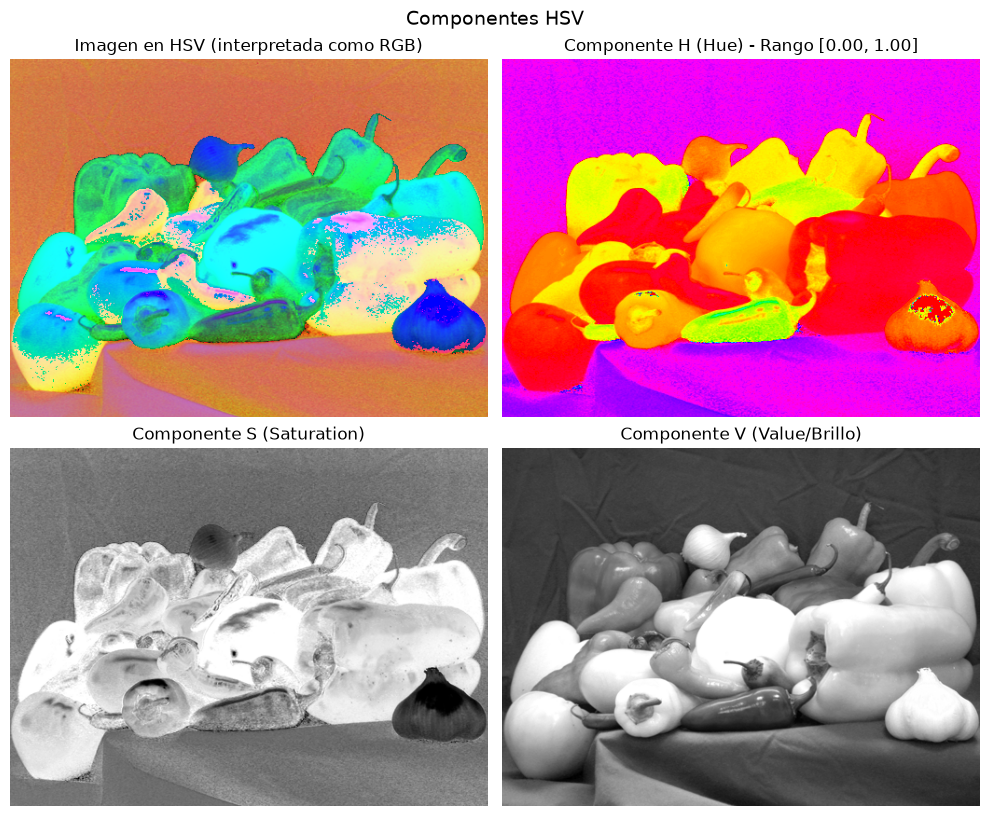

In [4]:
from skimage import color

# 1. Leer imagen peppers.png nuevamente
img_peppers = io.imread('peppers.png')
if img_peppers.ndim == 3 and img_peppers.shape[2] == 4:
    img_peppers = img_peppers[:, :, :3]

# 2. Convertir de RGB a HSV usando skimage.color
peppers_hsv = color.rgb2hsv(img_peppers)

# Extraer componentes individuales de HSV
H = peppers_hsv[:, :, 0]
S = peppers_hsv[:, :, 1]
V = peppers_hsv[:, :, 2]

# --- FIGURA 1: CANALES RGB ---
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8))

axes1[0, 0].imshow(img_peppers)
axes1[0, 0].set_title('Original RGB')
axes1[0, 0].axis('off')

axes1[0, 1].imshow(img_peppers[:, :, 0], cmap='gray')
axes1[0, 1].set_title('Canal R (Red)')
axes1[0, 1].axis('off')

axes1[1, 0].imshow(img_peppers[:, :, 1], cmap='gray')
axes1[1, 0].set_title('Canal G (Green)')
axes1[1, 0].axis('off')

axes1[1, 1].imshow(img_peppers[:, :, 2], cmap='gray')
axes1[1, 1].set_title('Canal B (Blue)')
axes1[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Componentes RGB', fontsize=14, y=1.02)
plt.show()

# --- FIGURA 2: CANALES HSV ---
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(peppers_hsv) # Matplotlib no interpreta HSV directamente en imshow, se verá extraño
axes2[0, 0].set_title('Imagen en HSV (interpretada como RGB)')
axes2[0, 0].axis('off')

axes2[0, 1].imshow(H, cmap='hsv') # Usamos el mapa de color 'hsv' para visualizar tonos
axes2[0, 1].set_title(f'Componente H (Hue) - Rango [{H.min():.2f}, {H.max():.2f}]')
axes2[0, 1].axis('off')

axes2[1, 0].imshow(S, cmap='gray')
axes2[1, 0].set_title('Componente S (Saturation)')
axes2[1, 0].axis('off')

axes2[1, 1].imshow(V, cmap='gray')
axes2[1, 1].set_title('Componente V (Value/Brillo)')
axes2[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Componentes HSV', fontsize=14, y=1.02)
plt.show()

## 2.2 Creación de un Mosaico de Colores

Generar mediante código una matriz sintética a color RGB de tamaño $192 \times 192$ que contenga un mosaico de $3 \times 3$ cuadrados con colores específicos:   
- Fila 1: Negro, Rojo, Azul.   
- Fila 2: Verde, Amarillo, Magenta.   
- Fila 3: Cian, Blanco, Negro.   

La imagen total mide $192 \times 192$ píxeles en 3 canales RGB (192, 192, 3). Como es una cuadrícula de $3 \times 3$, cada cuadrado individual mide $192 / 3 = 64$ píxeles de alto por $64$ de ancho.

Valores RGB en rango $[0, 1]$ o $[0, 255]$:
- Negro: [0, 0, 0]   
- Rojo: [1, 0, 0]   
- Verde: [0, 1, 0]   
- Azul: [0, 0, 1]   
- Amarillo (Rojo + Verde): [1, 1, 0]   
- Magenta (Rojo + Azul): [1, 0, 1]   
- Cian (Verde + Azul): [0, 1, 1]   
- Blanco (Rojo + Verde + Azul): [1, 1, 1]   

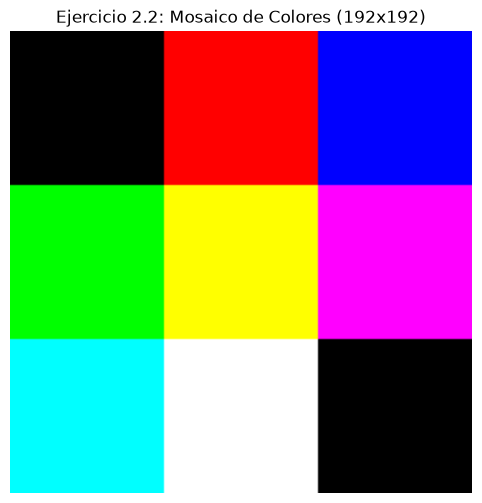

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear una matriz de ceros de tamaño 192 x 192 x 3 (tipo float32)
mosaic = np.zeros((192, 192, 3), dtype=np.float32)

# Tamaño de cada bloque de la cuadrícula
block_size = 64

# 2. Definir los colores RGB en rango [0, 1]
colors = {
    'black':   [0, 0, 0],
    'red':     [1, 0, 0],
    'blue':    [0, 0, 1],
    'green':   [0, 1, 0],
    'yellow':  [1, 1, 0],
    'magenta': [1, 0, 1],
    'cyan':    [0, 1, 1],
    'white':   [1, 1, 1]
}

# 3. Asignar los colores a cada bloque usando slicing de NumPy [y_start:y_end, x_start:x_end]
# Fila 0
mosaic[0:64, 0:64]     = colors['black']
mosaic[0:64, 64:128]   = colors['red']
mosaic[0:64, 128:192]  = colors['blue']

# Fila 1
mosaic[64:128, 0:64]    = colors['green']
mosaic[64:128, 64:128]  = colors['yellow']
mosaic[64:128, 128:192] = colors['magenta']

# Fila 2
mosaic[128:192, 0:64]    = colors['cyan']
mosaic[128:192, 64:128]  = colors['white']
mosaic[128:192, 128:192] = colors['black']

# 4. Mostrar el mosaico generado
plt.figure(figsize=(6, 6))
plt.imshow(mosaic)
plt.title('Ejercicio 2.2: Mosaico de Colores (192x192)')
plt.axis('off')
plt.show()

# 3. HISTOGRAMS

## 3.1 Cálculo y visualización de histogramas

Un histograma de intensidad de una imagen es una representación gráfica que muestra la distribución de sus niveles de gris. En el eje horizontal ($X$) se ubican todos los valores de luminosidad posibles (desde el 0, que representa el negro puro, hasta el 255, que representa el blanco puro), mientras que en el eje vertical ($Y$) se representa el número total de píxeles que poseen cada valor de intensidad.

Para calcular esta distribución en Python usaremos la función np.histogram(img, bins=256, range=(0, 256)), la cual recorre la matriz de la imagen y cuenta cuántos píxeles caen en cada uno de los 256 contenedores (bins). Es fundamental recordar que para pasar una matriz 2D de una imagen a np.histogram debemos aplanar la matriz a un vector de una sola dimensión mediante .ravel(). Finalmente, mostraremos la imagen original junto con su histograma representado mediante un gráfico de barras o líneas usando plt.hist() o plt.plot().

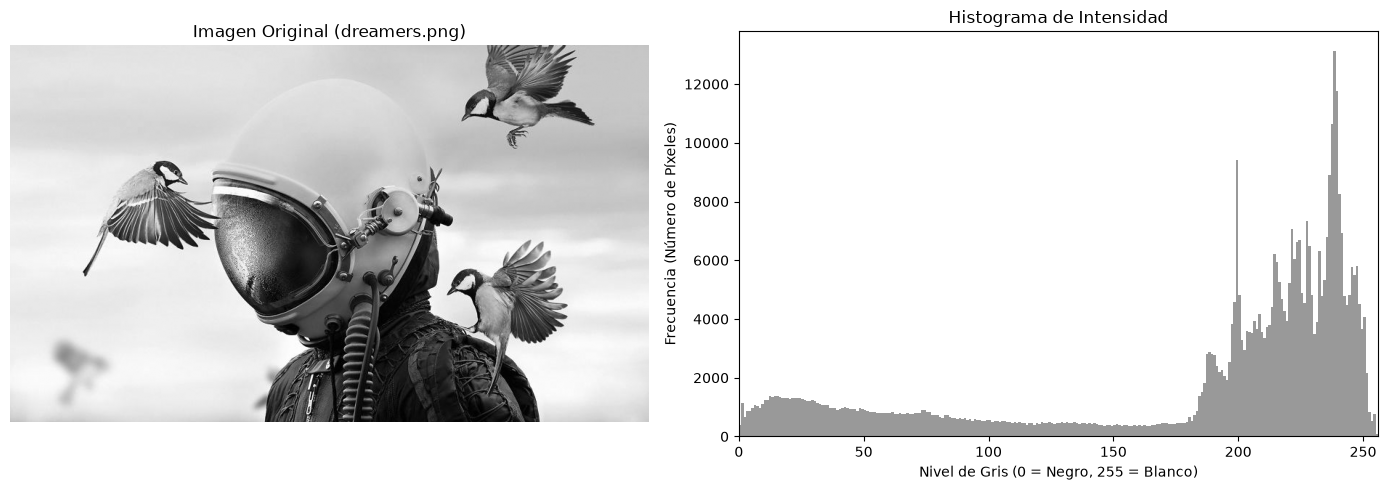

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# 1. Leer la imagen 'dreamers.png'
img_dreamers = io.imread('dreamers.png')

# 2. Calcular el histograma con NumPy
hist, bin_edges = np.histogram(img_dreamers.ravel(), bins=256, range=(0, 256))

# 3. Visualización de la imagen y su histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Imagen original
axes[0].imshow(img_dreamers, cmap='gray')
axes[0].set_title('Imagen Original (dreamers.png)')
axes[0].axis('off')

# Subplot 2: Histograma
axes[1].hist(img_dreamers.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.8)
axes[1].set_title('Histograma de Intensidad')
axes[1].set_xlabel('Nivel de Gris (0 = Negro, 255 = Blanco)')
axes[1].set_ylabel('Frecuencia (Número de Píxeles)')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

Dominio en zonas muy claras (rango 190 a 250): Se observa una gran concentración de píxeles con frecuencias elevadas y picos pronunciados. Esto se debe a que el cielo nublado del fondo y el casco del astronauta ocupan la mayor parte del área visual y corresponden a tonos grises muy claros y blancos.   

Zona de tonos oscuros y medios (rango 0 a 100): Se aprecia una pequeña elevación más extendida y plana en la zona izquierda. Esta representa los detalles oscuros del traje del astronauta, las plumas negras de las aves y las sombras de la escena.


## 3.1 (Continuación): Histograma con 32 bins, función propia e histograma normalizado

En esta segunda parte del ejercicio completaremos las siguientes 3 tareas:   
- Reducción de resolución del histograma (32 Bins): En lugar de dividir los tonos de gris en 256 niveles individuales, agruparemos los valores en 32 intervalos más anchos (agrupando de $8$ en $8$ niveles de gris). Para representarlo gráficamente de la forma estándar, utilizaremos un gráfico de barras con la función plt.bar().   
- Implementación de función propia histogram(x): Escribiremos manualmente la lógica del cálculo del histograma sin recurrir a bibliotecas externas. La idea consiste en inicializar un vector de ceros de tamaño $256$ y recorrer cada píxel de la matriz para incrementar el contador de la posición equivalente a su brillo.   
- Normalización (Función de Densidad de Probabilidad): Para interpretar el histograma como una Función de Densidad de Probabilidad (PDF), dividiremos cada frecuencia por el número total de píxeles de la imagen ($N \times M$). De este modo, la suma de todas las alturas del histograma será exactamente igual a $1$, y cada barra indicará la probabilidad de que un píxel al azar tenga ese tono de gris.   

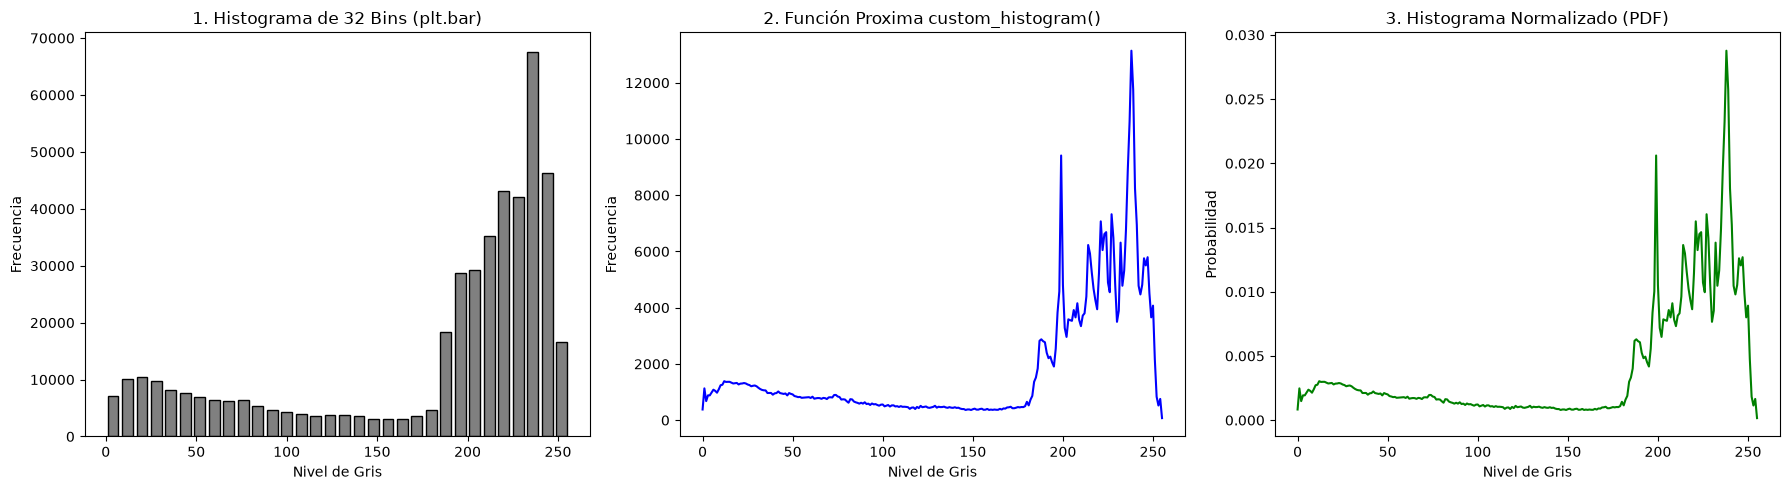

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# 1. Cargar imagen en escala de grises
img = io.imread('dreamers.png')

# --- TAREA 1: Función propia para calcular el histograma ---
def custom_histogram(x):
    # Vector de frecuencias de 256 elementos inicializado en 0
    h = np.zeros(256, dtype=int)
    # Vector de niveles de gris (0 a 255)
    b = np.arange(256)
    
    # Recorrer cada píxel de la imagen e incrementar su posición correspondiente
    for pixel in x.ravel():
        h[pixel] += 1
        
    return h, b

# Ejecutar nuestra función
h_custom, b_custom = custom_histogram(img)

# --- TAREA 2: Histograma agrupado en 32 Bins con plt.bar ---
# Agrupamos sumando los datos en bloques de 8 niveles (256 / 32 = 8)
counts_32, bin_edges_32 = np.histogram(img.ravel(), bins=32, range=(0, 256))
bin_centers_32 = (bin_edges_32[:-1] + bin_edges_32[1:]) / 2

# --- TAREA 3: Histograma normalizado (Función de Densidad de Probabilidad) ---
# Dividimos las frecuencias entre el número total de píxeles
pdf = h_custom / img.size

# --- VISUALIZACIÓN DE RESULTADOS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Histograma con 32 bins usando plt.bar
axes[0].bar(bin_centers_32, counts_32, width=6, color='gray', edgecolor='black')
axes[0].set_title('1. Histograma de 32 Bins (plt.bar)')
axes[0].set_xlabel('Nivel de Gris')
axes[0].set_ylabel('Frecuencia')

# Subplot 2: Resultado de la función propia custom_histogram
axes[1].plot(b_custom, h_custom, color='blue')
axes[1].set_title('2. Función Proxima custom_histogram()')
axes[1].set_xlabel('Nivel de Gris')
axes[1].set_ylabel('Frecuencia')

# Subplot 3: Histograma Normalizado (PDF)
axes[2].plot(b_custom, pdf, color='green')
axes[2].set_title('3. Histograma Normalizado (PDF)')
axes[2].set_xlabel('Nivel de Gris')
axes[2].set_ylabel('Probabilidad')

plt.tight_layout()
plt.show()

podemos apreciar claramente las diferencias y equivalencias de cada representación:   
1. Histograma de 32 Bins (Gráfico de barras): Al agrupar los 256 niveles de gris en solo 32 intervalos, la gráfica resulta mucho más suave y cuantificada, pero conserva intacta la tendencia bimodal del contraste (picos altos al final de la escala de grises y una base baja en los tonos oscuros).   
2. Función Propias custom_histogram(): Muestra exactamente la misma distribución que el histograma estándar calculado por librerías externas. Esto confirma que la lógica de iterar y acumular frecuencias de cada píxel según su valor $0-255$ funciona correctamente.   
3. Histograma Normalizado (PDF): La forma del gráfico es idéntica a la del histograma de 256 niveles, con la única diferencia de que el eje $Y$ se escala de $0$ a aproximadamente $0.028$. Al dividir entre el total de píxeles, ahora podemos decir, por ejemplo, que existe cerca de un $2.8\%$ de probabilidad de que un píxel aleatorio de la imagen tenga una intensidad cercana a $240$. 

## 3.2 Histogramas en Imágenes a Color

Aplicaremos la representación de histogramas a una imagen en color RGB (187_0070.jpg). A diferencia de una imagen en escala de grises que cuenta con una única matriz de intensidades, una imagen a color contiene tres matrices independientes (canales R, G y B).   

La guía nos pide dos tareas de visualización específicas:   
- Separación de componentes: Descomponer la imagen a color en sus 3 canales individuales y mostrarlos junto con la imagen original en un arreglo de $2 \times 2$ subplots.   
- Componentes con sus respectivos histogramas: Dividir una figura en 6 partes ($2 \times 3$ subplots) para mostrar cada canal de color de forma independiente justo arriba o al lado de su propio histograma de frecuencias.   

Para lograr esto, extraeremos los canales indexando la tercera dimensión de la matriz (img[:, :, 0] para Rojo, img[:, :, 1] para Verde, img[:, :, 2] para Azul) y calcularemos el histograma de cada canal por separado. 

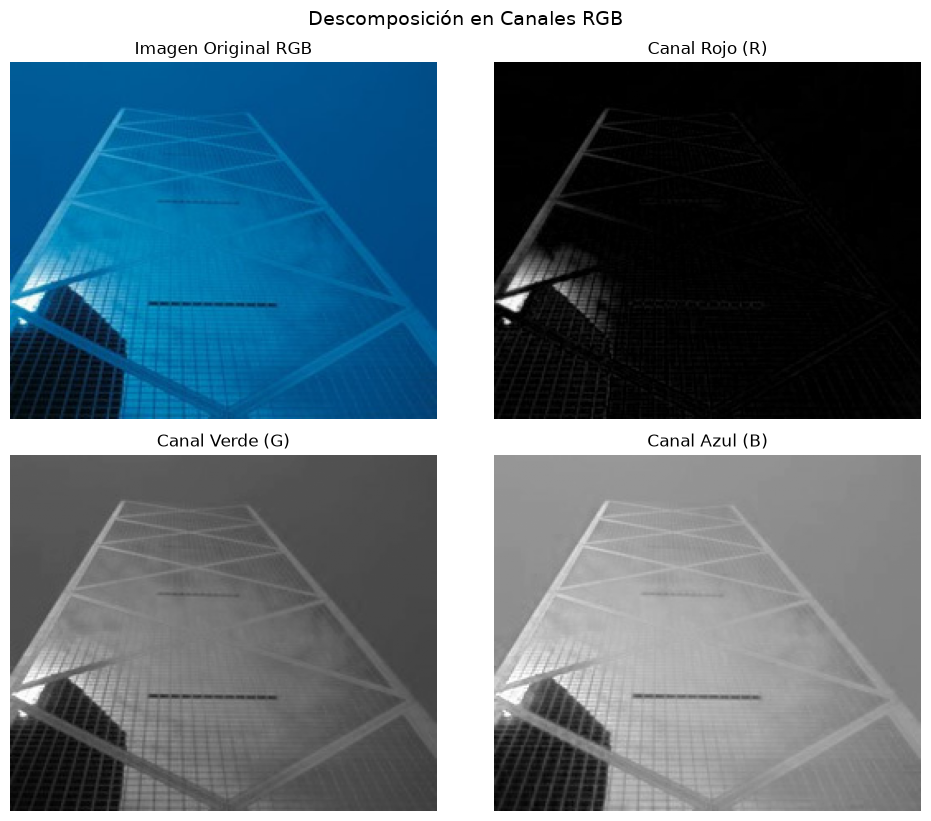

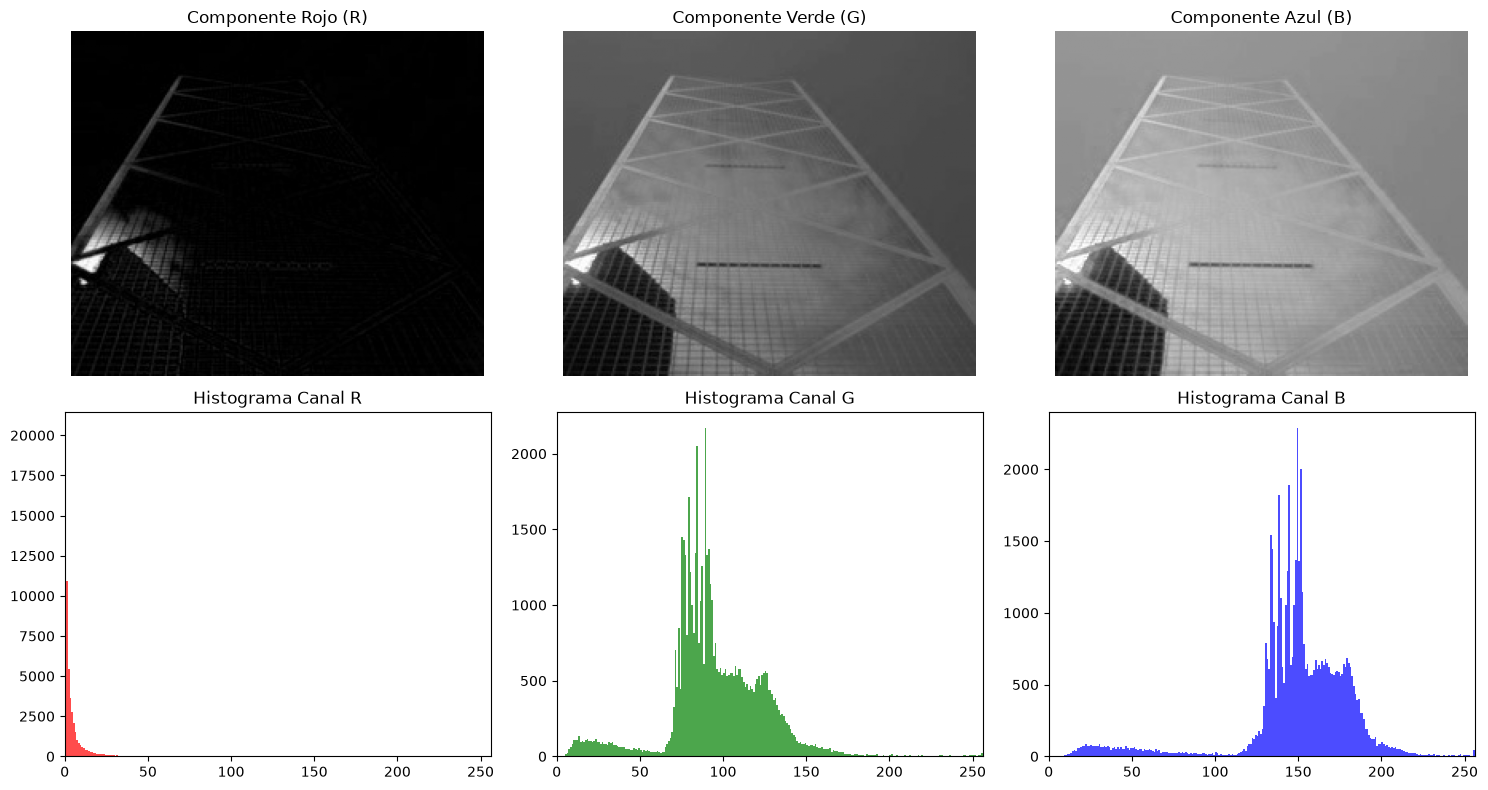

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# 1. Leer la imagen a color '187_0070.jpg'
img_color = io.imread('187_0070.jpg')

# Si la imagen tiene canal alfa (4 canales), nos quedamos solo con los 3 primeros (RGB)
if img_color.ndim == 3 and img_color.shape[2] == 4:
    img_color = img_color[:, :, :3]

# Extraer componentes de color
r_channel = img_color[:, :, 0]
g_channel = img_color[:, :, 1]
b_channel = img_color[:, :, 2]

# --- SUBPARTE A: Mostrar la imagen original y los 3 canales en una figura (2x2) ---
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8))

axes1[0, 0].imshow(img_color)
axes1[0, 0].set_title('Imagen Original RGB')
axes1[0, 0].axis('off')

axes1[0, 1].imshow(r_channel, cmap='gray')
axes1[0, 1].set_title('Canal Rojo (R)')
axes1[0, 1].axis('off')

axes1[1, 0].imshow(g_channel, cmap='gray')
axes1[1, 0].set_title('Canal Verde (G)')
axes1[1, 0].axis('off')

axes1[1, 1].imshow(b_channel, cmap='gray')
axes1[1, 1].set_title('Canal Azul (B)')
axes1[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Descomposición en Canales RGB', fontsize=14, y=1.02)
plt.show()

# --- SUBPARTE B: Figura de 6 partes (cada componente con su histograma) ---
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))

# Fila 1: Las 3 componentes en escala de grises
axes2[0, 0].imshow(r_channel, cmap='gray')
axes2[0, 0].set_title('Componente Rojo (R)')
axes2[0, 0].axis('off')

axes2[0, 1].imshow(g_channel, cmap='gray')
axes2[0, 1].set_title('Componente Verde (G)')
axes2[0, 1].axis('off')

axes2[0, 2].imshow(b_channel, cmap='gray')
axes2[0, 2].set_title('Componente Azul (B)')
axes2[0, 2].axis('off')

# Fila 2: Histogramas de cada componente
axes2[1, 0].hist(r_channel.ravel(), bins=256, range=(0, 256), color='red', alpha=0.7)
axes2[1, 0].set_title('Histograma Canal R')
axes2[1, 0].set_xlim([0, 256])

axes2[1, 1].hist(g_channel.ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
axes2[1, 1].set_title('Histograma Canal G')
axes2[1, 1].set_xlim([0, 256])

axes2[1, 2].hist(b_channel.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
axes2[1, 2].set_title('Histograma Canal B')
axes2[1, 2].set_xlim([0, 256])

plt.tight_layout()
plt.show()

- Canal Rojo (R): La mayor parte de sus píxeles están amontonados cerca del $0$ (negro puro). Esto ocurre porque la escena casi no tiene tonos cálidos o rojos, haciendo que la imagen de esta componente se vea sumamente oscura.   
- Canal Verde (G): Muestra un rango medio de valores concentrados entre el $70$ y el $130$. El verde aporta la estructura base y la luminosidad intermedia del edificio y el cielo.   
- Canal Azul (B): Su histograma está desplazado completamente hacia la derecha (valores entre $120$ y $200$). Esto confirma cuantitativamente que el azul es el color dominante en toda la escena (tanto en el cielo como en los reflejos de la estructura).

# 4. HISTOGRAM EQUALIZATION

## 4.1 Ecualización en imágenes en escala de grises

La ecualización de histograma es una técnica de procesamiento digital que busca redistribuir las intensidades de los píxeles de una imagen para que ocupen todo el rango dinámico disponible de forma uniforme ($0$ a $255$). Es ideal para mejorar imágenes con muy bajo contraste (imágenes "lavadas" u oscuras donde las intensidades están apretadas en una banda muy estrecha).   

Matemáticamente, la función de transformación que logra esta distribución es la Función de Distribución Acumulada (CDF) del histograma original:

$$T(r_k) = (L - 1) \sum_{j=0}^{k} p_r(r_j)$$

Donde $L=256$ representa los niveles de gris y $p_r(r_j)$ es la probabilidad de cada nivel. En Python usaremos skimage.exposure.equalize_hist(img) para obtener la versión ecualizada directamente, y calcularemos la suma acumulativa con np.cumsum() sobre el histograma para visualizar la curva acumulada de ambas imágenes.

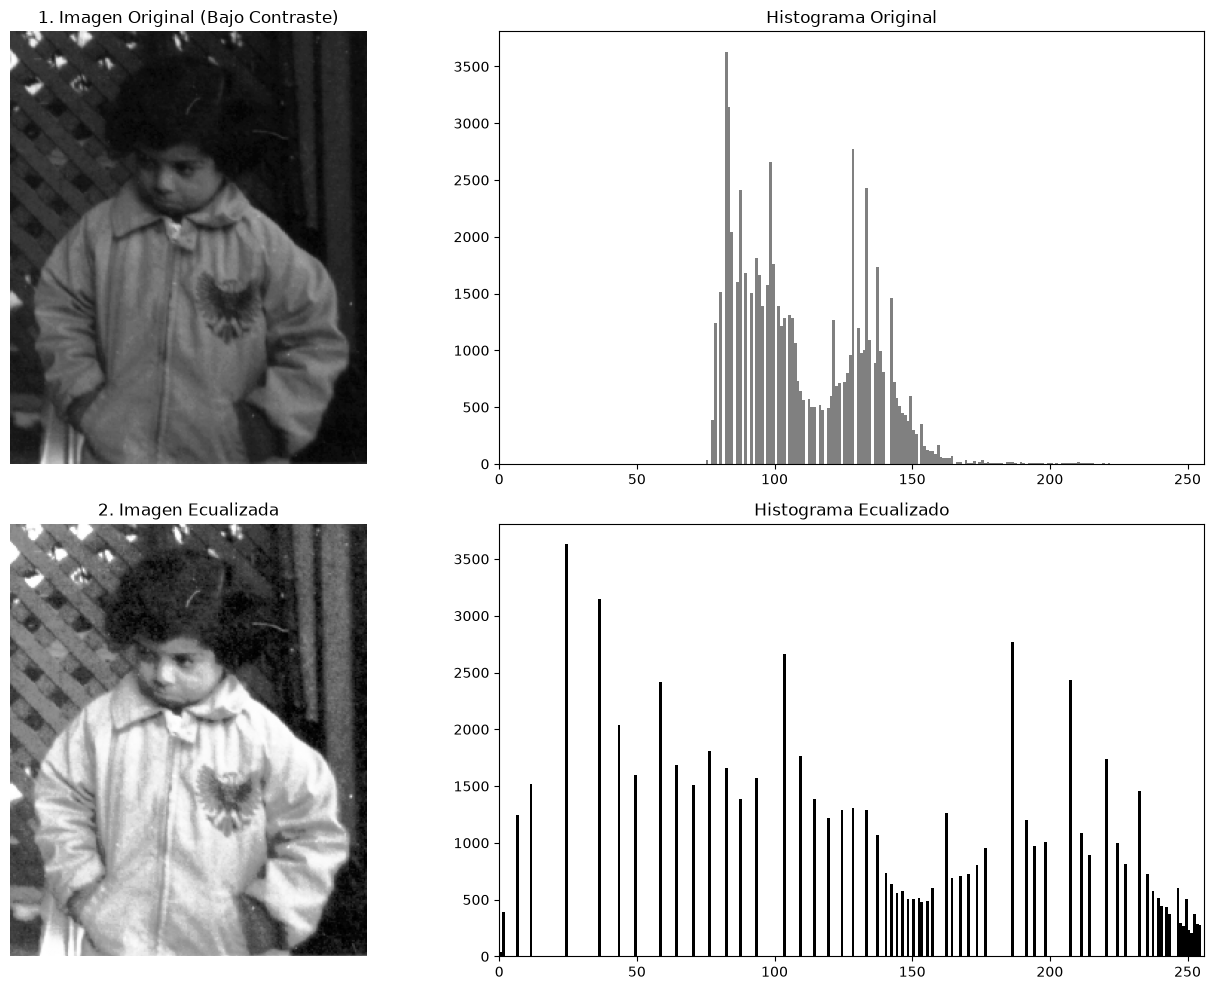

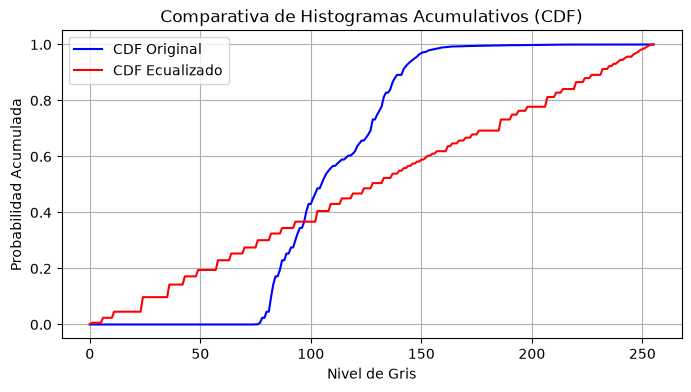

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure

# 1. Leer la imagen en escala de grises 'pout.tif'
img_pout = io.imread('pout.tif')

# 2. Aplicar ecualización de histograma
img_pout_eq = exposure.equalize_hist(img_pout)

# Convertir la imagen ecualizada a rango 0-255 en formato uint8 para histogramas consistentes
img_pout_eq_ubyte = (img_pout_eq * 255).astype(np.uint8)

# 3. Calcular histogramas acumulativos usando np.cumsum
hist_orig, _ = np.histogram(img_pout.ravel(), bins=256, range=(0, 256))
cdf_orig = hist_orig.cumsum() / hist_orig.sum()

hist_eq, _ = np.histogram(img_pout_eq_ubyte.ravel(), bins=256, range=(0, 256))
cdf_eq = hist_eq.cumsum() / hist_eq.sum()

# --- VISUALIZACIÓN EN SUBPLOTS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Imagen Original y su Histograma
axes[0, 0].imshow(img_pout, cmap='gray')
axes[0, 0].set_title('1. Imagen Original (Bajo Contraste)')
axes[0, 0].axis('off')

axes[0, 1].hist(img_pout.ravel(), bins=256, range=(0, 256), color='gray')
axes[0, 1].set_title('Histograma Original')
axes[0, 1].set_xlim([0, 256])

# B. Imagen Ecualizada y su Histograma
axes[1, 0].imshow(img_pout_eq, cmap='gray')
axes[1, 0].set_title('2. Imagen Ecualizada')
axes[1, 0].axis('off')

axes[1, 1].hist(img_pout_eq_ubyte.ravel(), bins=256, range=(0, 256), color='black')
axes[1, 1].set_title('Histograma Ecualizado')
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

# --- FIGURA ADICIONAL: HISTOGRAMAS ACUMULATIVOS (CDF) ---
plt.figure(figsize=(8, 4))
plt.plot(cdf_orig, color='blue', label='CDF Original')
plt.plot(cdf_eq, color='red', label='CDF Ecualizado')
plt.title('Comparativa de Histogramas Acumulativos (CDF)')
plt.xlabel('Nivel de Gris')
plt.ylabel('Probabilidad Acumulada')
plt.legend()
plt.grid(True)
plt.show()

Distribución de las Intensidades: En la imagen original pout.tif, todos los niveles de gris estaban comprimidos en una franja estrecha en el centro del rango (aproximadamente entre $75$ y $160$), lo que provocaba esa apariencia opaca y sin contraste. Tras la ecualización, las barras del histograma se "estiraron" a lo largo de todo el espectro dinámico ($0$ a $255$), haciendo que la chaqueta y los detalles del fondo resalten mucho más.   

Histograma Acumulativo (CDF): En la curva azul (CDF Original) se observa una pendiente muy inclinada únicamente en el medio, manteniéndose plana en las zonas oscuras y claras. La curva roja (CDF Ecualizado), en cambio, busca aproximarse a una línea recta diagonal, lo que demuestra matemáticamente una distribución uniforme de probabilidad de tonos a lo largo de la imagen.  

## 4.2 Ecualización en Imágenes a Color

Cuando se trabaja con imágenes a color, la ecualización no es tan directa como en escala de grises. El laboratorio plantea comparar dos enfoques distintos:   
- Ecualizar cada canal RGB por separado: Si aplicamos exposure.equalize_hist() independientemente a la matriz R, a la G y a la B, alteraremos la proporción de color entre los tres canales. Esto genera una distorsión severa del color, ya que cambia el tono (Hue) original de los objetos de la escena.   
- Ecualizar la componente V (Brillo) en el espacio HSV: Para evitar cambiar los colores reales de la foto, convertimos la imagen de RGB a HSV mediante skimage.color.rgb2hsv(). Luego, aplicamos la ecualización de histograma únicamente sobre el canal V (Value), manteniendo intactos los canales H (Tono) y S (Saturación). Finalmente, volvemos a convertir a RGB con skimage.color.hsv2rgb(). De esta manera se mejora el contraste respetando los colores originales. 

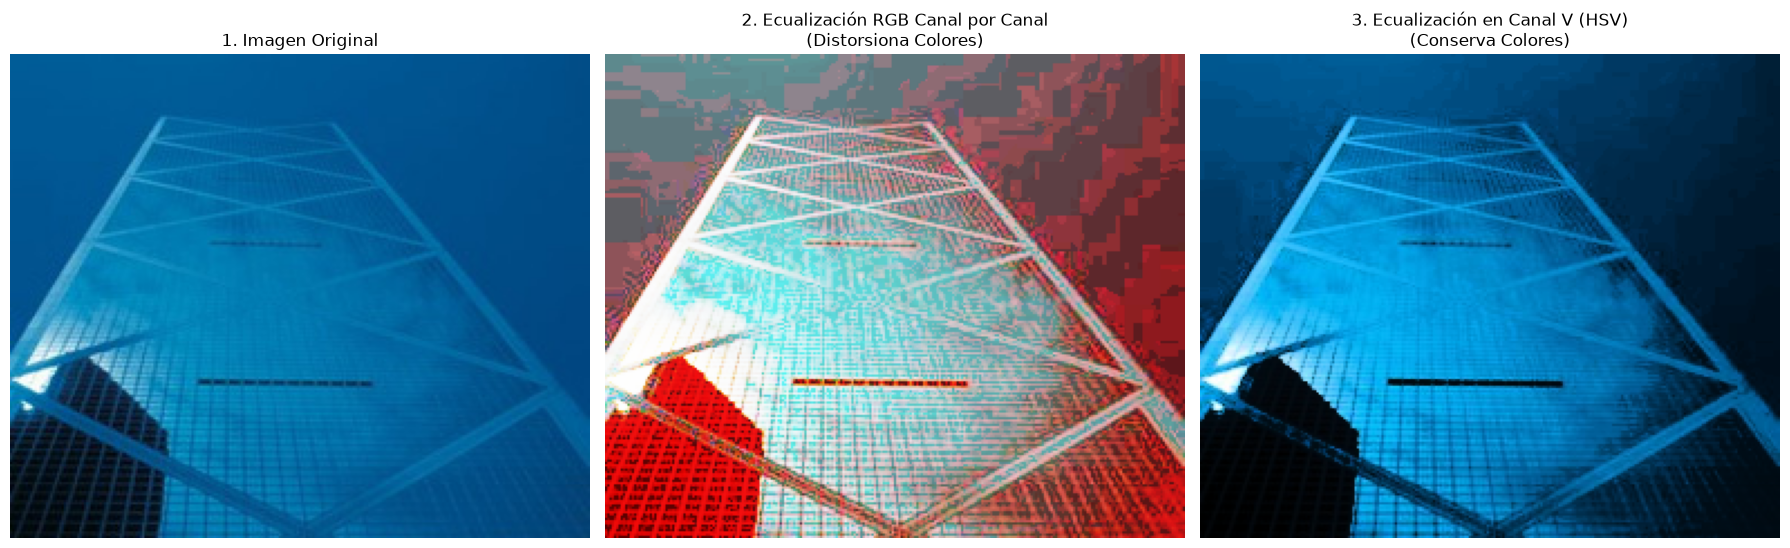

In [10]:
import matplotlib.pyplot as plt
from skimage import io, color, exposure

# 1. Leer la imagen a color '187_0070.jpg'
img_color = io.imread('187_0070.jpg')
if img_color.ndim == 3 and img_color.shape[2] == 4:
    img_color = img_color[:, :, :3]

# --- ENFOQUE 1: Ecualización independiente en cada canal RGB ---
img_eq_rgb = img_color.copy()
for i in range(3):
    img_eq_rgb[:, :, i] = (exposure.equalize_hist(img_color[:, :, i]) * 255).astype('uint8')

# --- ENFOQUE 2: Ecualización en el canal V del espacio HSV ---
img_hsv = color.rgb2hsv(img_color)
# Ecualizar únicamente la componente V (brillo)
img_hsv[:, :, 2] = exposure.equalize_hist(img_hsv[:, :, 2])
# Reconvertir de HSV a RGB
img_eq_hsv = color.hsv2rgb(img_hsv)

# --- VISUALIZACIÓN DE COMPARATIVA ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_color)
axes[0].set_title('1. Imagen Original')
axes[0].axis('off')

axes[1].imshow(img_eq_rgb)
axes[1].set_title('2. Ecualización RGB Canal por Canal\n(Distorsiona Colores)')
axes[1].axis('off')

axes[2].imshow(img_eq_hsv)
axes[2].set_title('3. Ecualización en Canal V (HSV)\n(Conserva Colores)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

2. Ecualización RGB Canal por Canal: Al procesar cada canal de forma independiente, el canal Rojo (que originalmente tenía valores muy bajos) se estiró artificialmente hasta ocupar todo el rango $0-255$. Esto alteró la proporción cromática y generó manchas rojas falsas en zonas oscuras y sombras, distorsionando por completo la escena.   
3. Ecualización en el Canal V (HSV): Al modificar únicamente el brillo/luminosidad (componente $V$) y mantener intactas las componentes de tono ($H$) y saturación ($S$), se logró resaltar la textura, los detalles del edificio y el contraste del fondo sin alterar el color azul característico de la fotografía. 

# 5.1 FILTERS

Un filtro Gaussiano es un filtro paso bajo que suaviza la imagen promediando cada píxel con sus vecinos mediante una función de distribución Gaussiana bidimensional:

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

El parámetro clave aquí es la desviación estándar ($\sigma$ o sigma):   
- $\sigma$ pequeño (ej. 1 o 2): Aplica un suavizado leve, conservando la mayoría de los bordes y detalles.   
- $\sigma$ grande (ej. 5 o 10): Difumina la imagen fuertemente, atenuando los detalles de alta frecuencia y bordes.   

En este ejercicio aplicaremos skimage.filters.gaussian() sobre la imagen dreamers.png utilizando diferentes valores de $\sigma$ para observar cómo afecta el nivel de difusión.  

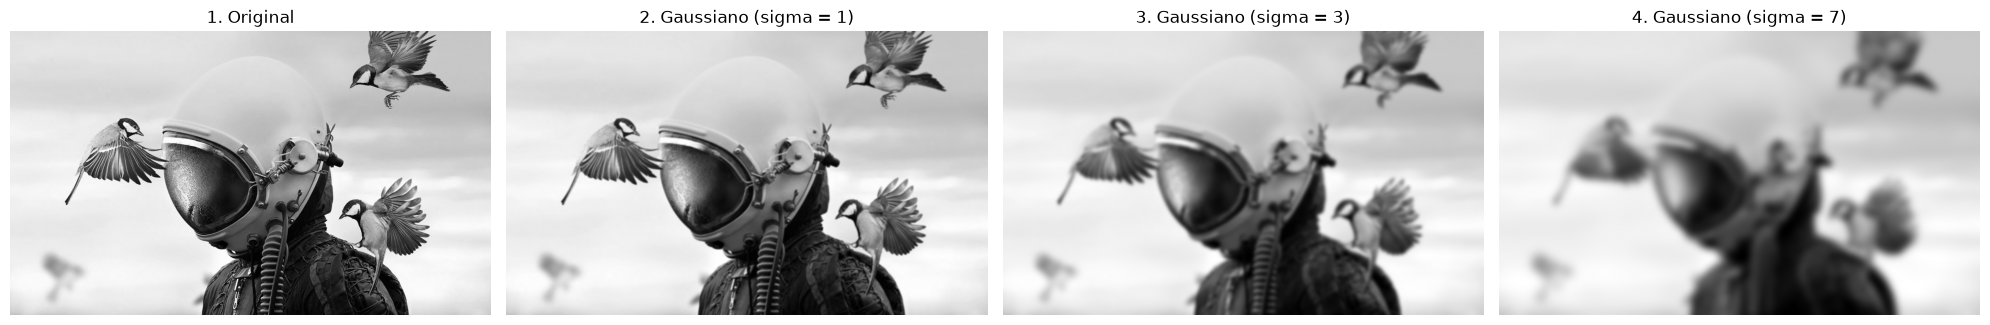

In [11]:
import matplotlib.pyplot as plt
from skimage import io, filters

# 1. Leer la imagen en escala de grises 'dreamers.png'
img_dreamers = io.imread('dreamers.png')

# 2. Aplicar filtros Gaussianos con diferentes valores de sigma
img_g1 = filters.gaussian(img_dreamers, sigma=1)
img_g3 = filters.gaussian(img_dreamers, sigma=3)
img_g7 = filters.gaussian(img_dreamers, sigma=7)

# --- VISUALIZACIÓN DE RESULTADOS ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_dreamers, cmap='gray')
axes[0].set_title('1. Original')
axes[0].axis('off')

axes[1].imshow(img_g1, cmap='gray')
axes[1].set_title('2. Gaussiano (sigma = 1)')
axes[1].axis('off')

axes[2].imshow(img_g3, cmap='gray')
axes[2].set_title('3. Gaussiano (sigma = 3)')
axes[2].axis('off')

axes[3].imshow(img_g7, cmap='gray')
axes[3].set_title('4. Gaussiano (sigma = 7)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

En las cuatro imágenes de la secuencia se puede observar claramente el impacto del aumento de la desviación estándar ($\sigma$) en el filtro Gaussiano:   
- $\sigma = 1$: Aplica un filtro sumamente suave que elimina apenas el ruido fino de alta frecuencia sin perder la nitidez de los bordes ni la textura de las plumas de las aves.   
- $\sigma = 3$: El desenfoque se vuelve más evidente; los detalles finos y las texturas pequeñas comienzan a borrarse, aunque la estructura general del astronauta se mantiene.   
- $\sigma = 7$: Causa una pérdida masiva de altas frecuencias, volviendo la imagen totalmente difusa e imprecisa, donde los pájaros pequeños pierden casi todo su detalle fino y sus bordes.

# 5.2 HIGH-PASS FILTERS

Los filtros paso alto destacan las zonas donde ocurren cambios abruptos de intensidad en la imagen (los bordes o contornos) y atenúan las áreas homogéneas.   
El operador Sobel calcula una aproximación del gradiente de intensidad de la imagen. La guía nos pide realizar las siguientes tareas:   
- Bordes Horizontales (filters.sobel_h): Utiliza una máscara $3 \times 3$ especial para detectar cambios bruscos de intensidad en dirección vertical (lo que resalta las líneas y bordes horizontales):

$$\begin{bmatrix} 1 & 2 & 1 \\ 0 & 0 & 0 \\ -1 & -2 & -1 \end{bmatrix}$$
   
- Valor Absoluto y Umbralización: Dado que el filtro produce valores positivos y negativos, se le aplica el valor absoluto np.abs() para observar la magnitud del cambio. Luego, se aplica un umbral (por ejemplo, $T > 0.1$) para convertir la imagen a un formato binario y resaltar solo los contornos más marcados.   

- Magnitud del Gradiente (filters.sobel): Combina la respuesta horizontal ($s_h$) y vertical ($s_v$) mediante la fórmula de la magnitud del gradiente:

$$\nabla I = \sqrt{s_h^2 + s_v^2}$$

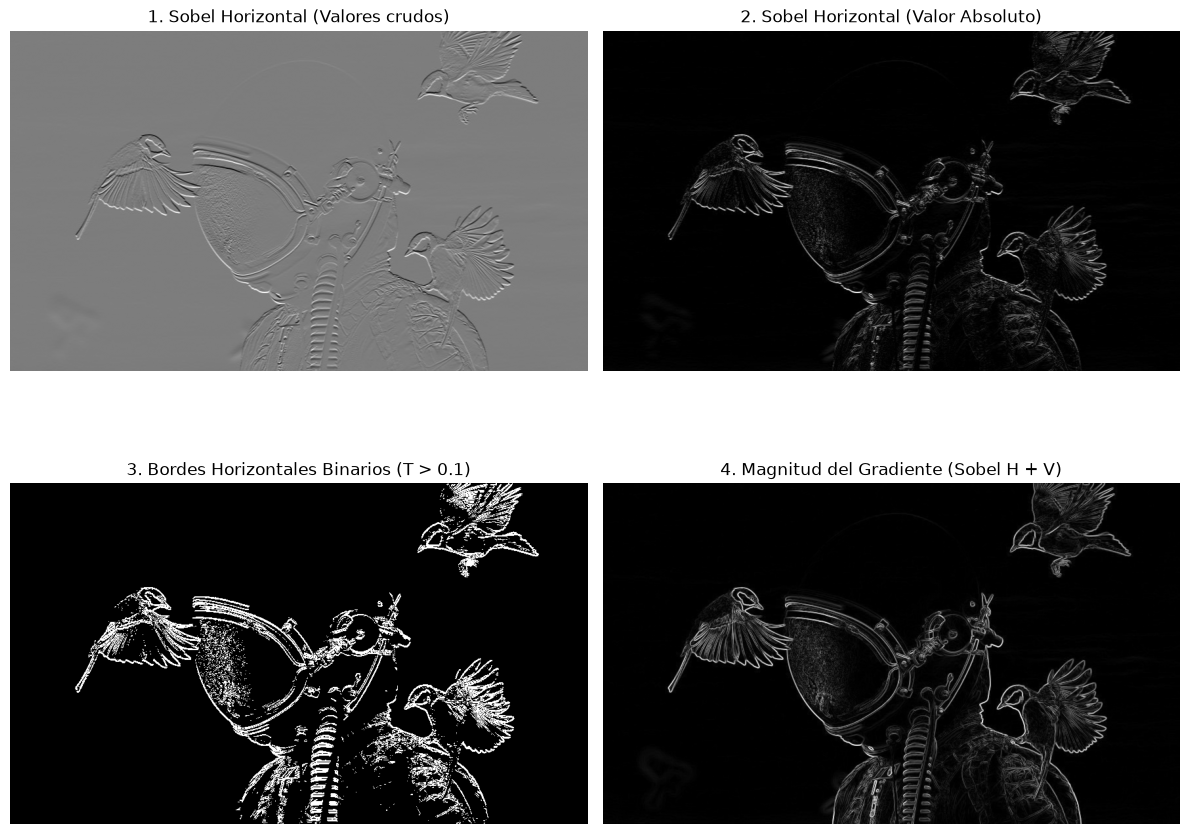

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters

# 1. Cargar la imagen 'dreamers.png'
img_dreamers = io.imread('dreamers.png')

# Convertir la imagen a flotante [0, 1] si no lo está para operaciones matematicas de Sobel
if img_dreamers.dtype == np.uint8:
    img_float = img_dreamers / 255.0
else:
    img_float = img_dreamers.copy()

# 2. Detección de Bordes Horizontales (Sobel H)
sobel_h_raw = filters.sobel_h(img_float)
sobel_h_abs = np.abs(sobel_h_raw)

# Aplicar umbralización a los bordes horizontales
threshold = 0.1
sobel_h_bin = sobel_h_abs > threshold

# 3. Magnitud del Gradiente (Sobel completo: Horizontal + Vertical)
sobel_magnitude = filters.sobel(img_float)

# --- VISUALIZACIÓN DE RESULTADOS ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Respuesta del Filtro Sobel Horizontal
axes[0, 0].imshow(sobel_h_raw, cmap='gray')
axes[0, 0].set_title('1. Sobel Horizontal (Valores crudos)')
axes[0, 0].axis('off')

# Subplot 2: Valor Absoluto del Sobel Horizontal
axes[0, 1].imshow(sobel_h_abs, cmap='gray')
axes[0, 1].set_title('2. Sobel Horizontal (Valor Absoluto)')
axes[0, 1].axis('off')

# Subplot 3: Bordes Horizontales Binarios (Umbralizado)
axes[1, 0].imshow(sobel_h_bin, cmap='gray')
axes[1, 0].set_title(f'3. Bordes Horizontales Binarios (T > {threshold})')
axes[1, 0].axis('off')

# Subplot 4: Magnitud del Gradiente (Sobel Completo)
axes[1, 1].imshow(sobel_magnitude, cmap='gray')
axes[1, 1].set_title('4. Magnitud del Gradiente (Sobel H + V)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

En los cuatro cuadrantes podemos observar cómo funciona el cálculo de derivadas y detección de bordes mediante el operador Sobel:

1. Sobel Horizontal Crudo: Genera un efecto de relieve o "tallado en piedra". Esto se debe a que las diferencias de brillo producen valores negativos cuando el cambio es de claro a oscuro, y positivos cuando es de oscuro a claro. El fondo gris representa el cero.
2. Valor Absoluto: Al tomar np.abs(), convertimos todas las variaciones a magnitudes positivas, iluminando tanto las transiciones de claro-a-oscuro como las de oscuro-a-claro. Destacan principalmente los bordes horizontales del visor del casco y las alas de los pájaros.
3. Bordes Binarios: Tras aplicar el umbral de $0.1$, obtenemos una máscara binaria donde solo sobreviven las discontinuidades más marcadas.
4. Magnitud del Gradiente (Sobel H + V): Combina ambas componentes ortogonales ($\nabla I = \sqrt{s_h^2 + s_v^2}$), entregando un mapa de contornos completo y uniforme en todas las direcciones.

## 5.2.1

## 5.2.2

## 5.2.3

# 5.3 MEDIAN FILTER